In [1]:
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelEncoder
import keras
import pandas as pd
import numpy as np
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score

deer


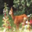

In [2]:
labels = pd.read_csv('cifar10Labels.csv', index_col=0)

img_idx = 1527
print(labels.label[img_idx])
Image.open('cifar10/'+str(img_idx)+'.png')

In [3]:
from sklearn.model_selection import train_test_split

y_train, y_test = train_test_split(labels.label, test_size=0.3, random_state=42)
train_idx, test_idx = y_train.index, y_test.index



In [4]:
temp=[]
for img_idx in y_train.index :
    img_path = os.path.join('cifar10/'+str(img_idx)+'.png')
    img = np.array(Image.open(img_path)).astype('float32')
    temp.append(img)
x_train = np.stack(temp)

In [5]:
temp = []
for img_idx in y_test.index :
    img_path = os.path.join('cifar10/'+str(img_idx)+'.png')
    img = np.array(Image.open(img_path)).astype('float32')
    temp.append(img)
x_test = np.stack(temp)

In [6]:
X_train = x_train/255.
X_test = x_test/255

In [7]:
encode_x = LabelEncoder()
y_train_encoded = encode_x.fit_transform(y_train)
y_train = keras.utils.to_categorical(y_train_encoded)

y_test_encoded = encode_x.transform(y_test)
y_test = keras.utils.to_categorical(y_test_encoded)

In [8]:
from sklearn.metrics import accuracy_score
num_classes = 10
model = keras.models.Sequential([    
    # Adding first convolutional layer
    keras.layers.Conv2D(filters=32, kernel_size=(4, 4), strides=1, padding='same', activation='relu', 
                        kernel_regularizer=keras.regularizers.l2(0.001), input_shape=(32, 32, 3), name='Conv_1'), 
    # Normalizing the parameters from last layer to speed up the performance (optional)
    keras.layers.BatchNormalization(name='BN_1'),
    # Adding first pooling layer
    keras.layers.MaxPool2D(pool_size=(2, 2), name='MaxPool_1'),
    # Adding second convolutional layer
    keras.layers.Conv2D(filters=64, kernel_size=(4, 4), strides=1, padding='same', activation='relu', 
                        kernel_regularizer=keras.regularizers.l2(0.001), name='Conv_2'),    
    keras.layers.BatchNormalization(name='BN_2'),
    # Adding second pooling layer
    keras.layers.MaxPool2D(pool_size=(2, 2), name='MaxPool_2'),
    # Flattens the input
    keras.layers.Flatten(name='Flat'),
    # Fully-Connected layer
    keras.layers.Dense(num_classes, activation='softmax', name='pred_layer')    
])
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(), 
              metrics=['accuracy'])
cpfile = r'CIFAR10_checkpoint.keras' # Weights to be stored in HDF5 format
cb_checkpoint = keras.callbacks.ModelCheckpoint(cpfile, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
epochs = 5
model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, callbacks=[cb_checkpoint])
actual_train = [np.argmax(x) for x in y_train]
predicted_train = np.argmax(model.predict(X_train), axis=1)
print('Train accuracy: ', accuracy_score(actual_train, predicted_train) * 100) # Change metric for more.
actual_test = [np.argmax(x) for x in y_test]
predicted_test = np.argmax(model.predict(X_test), axis=1)
print('Test accuracy: ', accuracy_score(actual_test, predicted_test) * 100) # Change metric for more.


Epoch 1/5
873/875 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4050 - loss: 2.0499
Epoch 1: val_accuracy improved from None to 0.45171, saving model to CIFAR10_checkpoint.keras

Epoch 1: finished saving model to CIFAR10_checkpoint.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.4707 - loss: 1.7370 - val_accuracy: 0.4517 - val_loss: 1.7871
Epoch 2/5
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5942 - loss: 1.2629
Epoch 2: val_accuracy improved from 0.45171 to 0.51686, saving model to CIFAR10_checkpoint.keras

Epoch 2: finished saving model to CIFAR10_checkpoint.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.6005 - loss: 1.2447 - val_accuracy: 0.5169 - val_loss: 1.6314
Epoch 3/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6538 - loss: 1.0615
Epoch 3: val_accuracy improved from 0.51686 to 0.59457, saving model to CIFAR10_checkpoint.keras

Epoch 3: finished saving model to CIFAR10_checkpoint.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 27s 30m

In [9]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv_1 (Conv2D)                 │ (None, 32, 32, 32)     │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 32, 32, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_1 (MaxPooling2D)        │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 16, 16, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 16, 16, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool_2 (MaxPooling2D)        │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flat (Flatten)                  │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pred_layer (Dense)              │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,880 (886.25 KB)

 Trainable params: 75,562 (295.16 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 151,126 (590.34 KB)

In [10]:
# Compiling the model
model.compile(loss='categorical_crossentropy', 
              optimizer=keras.optimizers.Adam(), 
              metrics=['accuracy'])
cpfile = 'CIFAR10_checkpoint.keras' # Weights to be stored in HDF5 format
cb_checkpoint = keras.callbacks.ModelCheckpoint(cpfile, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
epochs = 5
model.fit(X_train, y_train, epochs=epochs, validation_split=0.2, callbacks=[cb_checkpoint])


Epoch 1/5
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7410 - loss: 0.8216
Epoch 1: val_accuracy improved from None to 0.63557, saving model to CIFAR10_checkpoint.keras

Epoch 1: finished saving model to CIFAR10_checkpoint.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 28s 31ms/step - accuracy: 0.7277 - loss: 0.8597 - val_accuracy: 0.6356 - val_loss: 1.2274
Epoch 2/5
875/875 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7684 - loss: 0.7420
Epoch 2: val_accuracy improved from 0.63557 to 0.66100, saving model to CIFAR10_checkpoint.keras

Epoch 2: finished saving model to CIFAR10_checkpoint.keras
875/875 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.7579 - loss: 0.7756 - val_accuracy: 0.6610 - val_loss: 1.1455
Epoch 3/5
874/875 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7890 - loss: 0.6849
Epoch 3: val_accuracy did not improve from 0.66100
875/875 ━━━━━━━━━━━━━━━━━━━━ 27s 31ms/step - accuracy: 0.7784 - loss: 0.7223 - val_accuracy: 0.5601 - val_loss: 1.7654
Epoch 4/5
874/875 ━━━━━

In [11]:
# Making predictions
pred_probs = model.predict(X_test[:10])
pred_indices = np.argmax(pred_probs, axis=1)
pred = encode_x.inverse_transform(pred_indices)

# Converting one-hot test labels back to class indices for comparison
act_indices = np.argmax(y_test[:10], axis=1)
act = encode_x.inverse_transform(act_indices)

# Creating results table
res = pd.DataFrame([pred, act]).T
res.columns = ['predicted', 'actual']
res

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


,predicted,actual
0,cat,horse
1,ship,ship
2,ship,airplane
3,frog,frog
4,automobile,automobile
5,cat,frog
6,cat,ship
7,truck,airplane
8,frog,frog
9,truck,dog


Classes: ['airplane' 'automobile' 'bird' 'cat' 'deer' 'dog' 'frog' 'horse' 'ship'
 'truck']


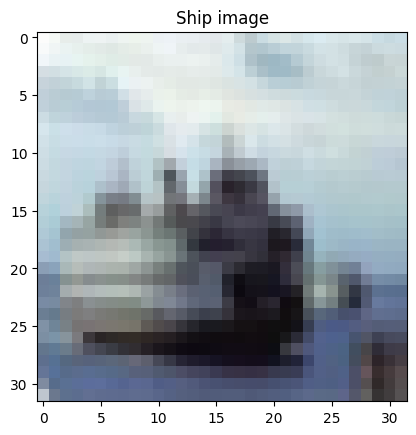

In [12]:
# Indexes of categories for our model
classes = encode_x.inverse_transform(np.arange(10))
print(f"Classes: {classes}")

# Fetching and displaying the ship image using PIL (Image.open)
img_path = 'cifar10/' + str(test_idx[6]) + '.png'
ship_img = Image.open(img_path)

plt.imshow(ship_img)
plt.title('Ship image')
plt.show()